In [1]:
import import_ipynb
# from KNN_SL import KNNSL
# KNNSL.knn()
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
data =  np.loadtxt('/home/gayratbek/university/leetcode/diabet_new.txt')
# def None_tekshir():
#     for i in range(9):
#         nullar = []
#         x =  data[:,i]
#         # for j in range(i+1,9):
#         #     if x == 0:
#         #         nullar.append(f"{i}{j}")
#         print(x[:,1])
# None_tekshir()
n_data = 0
def korrelyatsiy():
    natija = {}
    for i in range(9):
        x = data[:, i] 
        x_mean = np.mean(x)
        for j in range(i+1, 9):
            y = data[:, j]
            y_mean = np.mean(y)
        
            numerator = np.sum((x - x_mean) * (y - y_mean))
            denominator = np.sqrt(np.sum((x - x_mean)**2) * np.sum((y - y_mean)**2))
        
            if denominator != 0:
                corr = numerator / denominator
                natija[f"{i} va {j}"] = float(corr)
            else:
                natija[f"{i} va {j}"] = 'aniqlab bo`lmadi (variatsiya 0)'
    # print(natija)
    # ochirish 8 qator sababbi korrelatsiya 54
    global n_data
    n_data = np.delete(data,7,axis=1)
    print(np.shape(n_data))
korrelyatsiy()
n_natija = {}
for i in range(8):
    xx = n_data[:,i]
    x_meann  = np.mean(xx)
    for j in range(i+1,8):
         summ = np.sum((xx - x_meann)**2)
         n_natija[f"{i+1}"] = float(summ / (len(data) -1 ))
print(n_natija)
def outliearmi():
    outliear = {}
    for i  in range(data.shape[1]):
        x = data[:,i]
        q1 = np.percentile(x,25)
        q3 = np.percentile(x, 75)
        iqr = q3 - q1
        bosh_oraliq = x  < q1  - 1.5 * iqr
        oxirgi_oraliq = x > q3 + 1.5 * iqr
        outliears = x[bosh_oraliq | oxirgi_oraliq]
        outliear[f"ustun_{i}"] = outliears
    print(outliear)
outliearmi()
# def grafik_korsatadi():
#     for i in range(1,8):
#         x = n_data[:,i] 
#         for j in range(i+1,8):
#             randommi = ['red','yellow','black','orange','green','pink']
#             ran =  random.choice(randommi)
#             plt.scatter(n_data[:,i], n_data[:,j],color=ran , label= 'Natijalar')
#             plt.xlabel(f"data{i-1}{j-1} 1- qatorniki")
#             plt.ylabel(f"data{i}{j} 2-qatorniki")
#             plt.title("Feature lar orasidagi bog'liqlik grafigi")
#             plt.legend()
#             plt.savefig(f'{i}{j} jadvalni Matplotlibdagi grafigi')
#             plt.show()

(768, 8)
{'1': 11.354056320621465, '2': 1022.2483142519557, '3': 374.6472712271838, '4': 254.47324532811822, '5': 13281.180077955238, '6': 62.15998395738266, '7': 0.1097786378731394}
{'ustun_0': array([15., 17., 14., 14.]), 'ustun_1': array([0., 0., 0., 0., 0.]), 'ustun_2': array([  0.,   0.,  30., 110.,   0.,   0.,   0.,   0., 108., 122.,  30.,
         0., 110.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0., 108.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0., 110.,   0.,  24.,   0.,   0.,   0.,   0., 114.,   0.,   0.,
         0.]), 'ustun_3': array([99.]), 'ustun_4': array([543., 846., 342., 495., 325., 485., 495., 478., 744., 370., 680.,
       402., 375., 545., 360., 325., 465., 325., 415., 579., 474., 328.,
       480., 326., 330., 600., 321., 440., 540., 480., 335., 387., 392.,
       510.]), 'ustun_5': array([ 0. ,  0. ,  0. ,  0. , 53.2, 55. ,  0. , 67.1, 52.3, 52.3, 52.9,
        0. ,  0. , 59.4,  0. ,  0. , 57.3,  0. ,  0. ]), 'ustun_

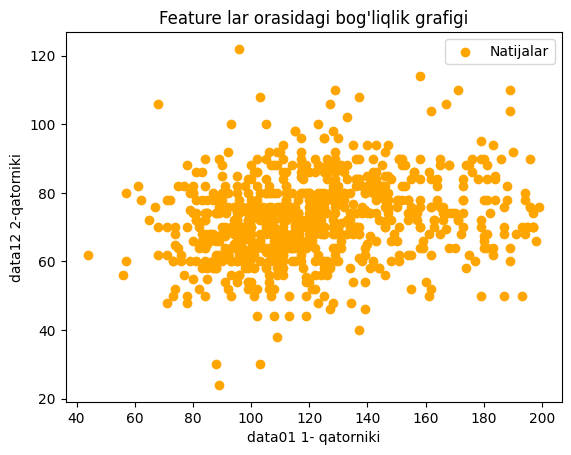

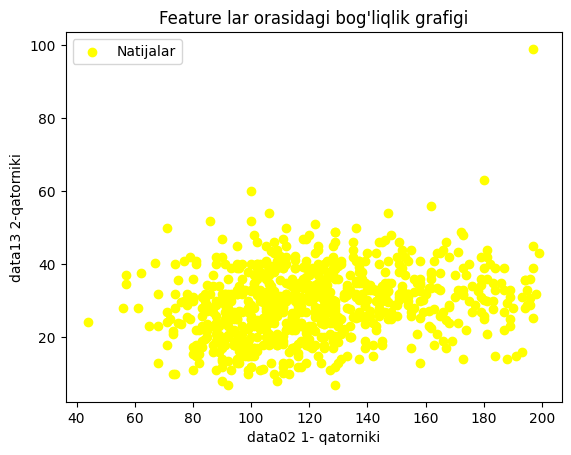

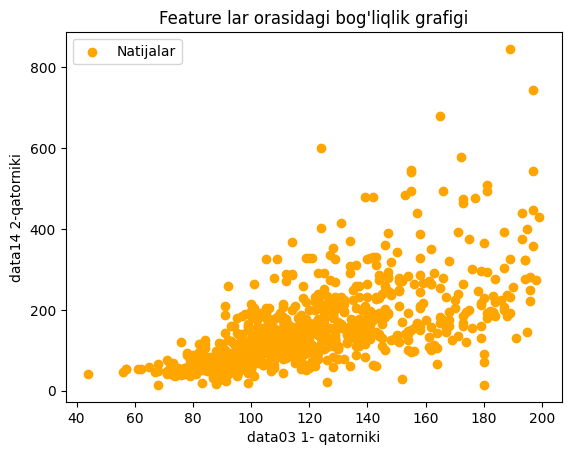

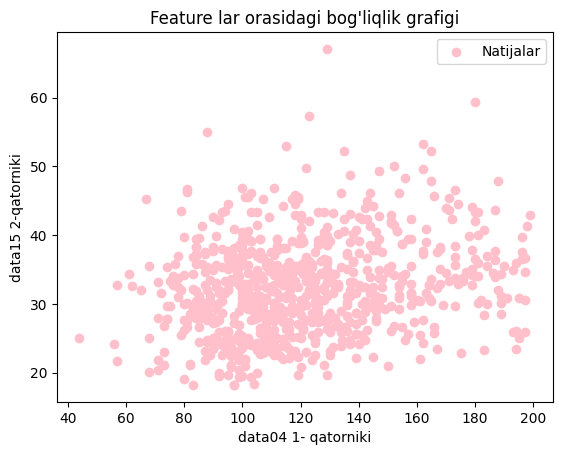

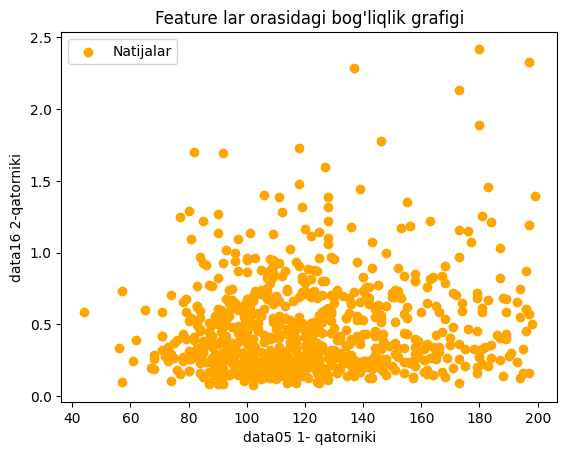

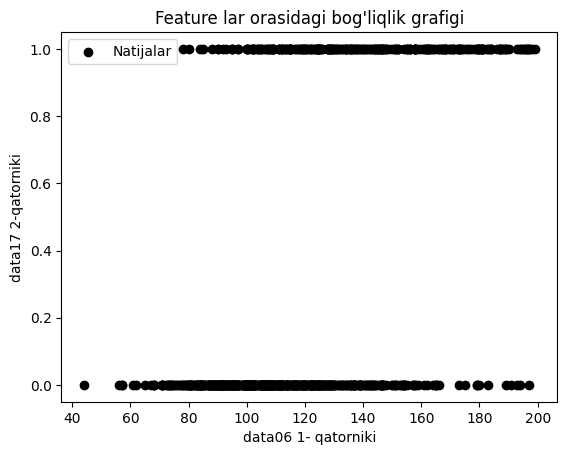

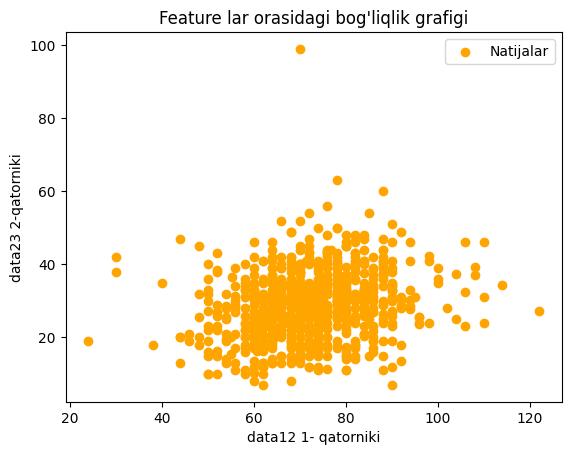

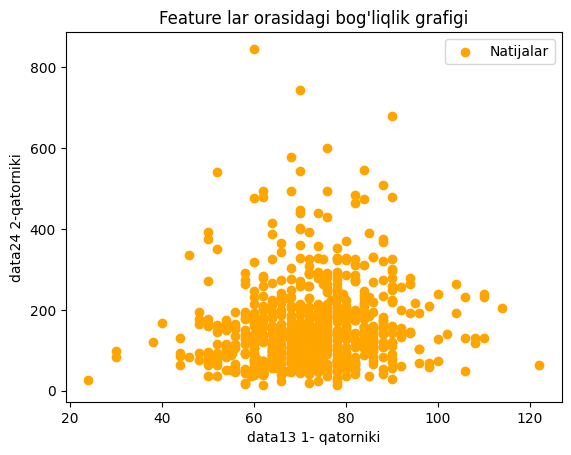

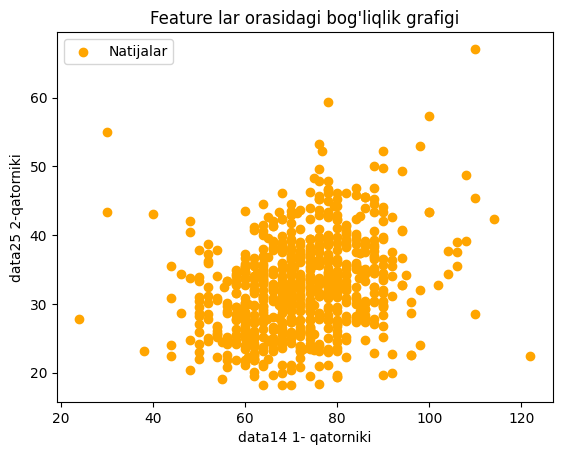

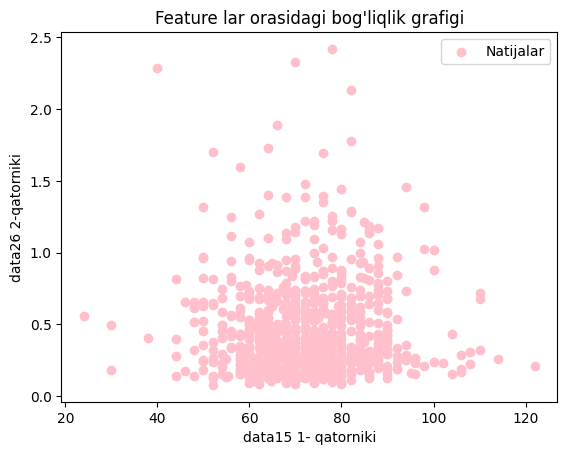

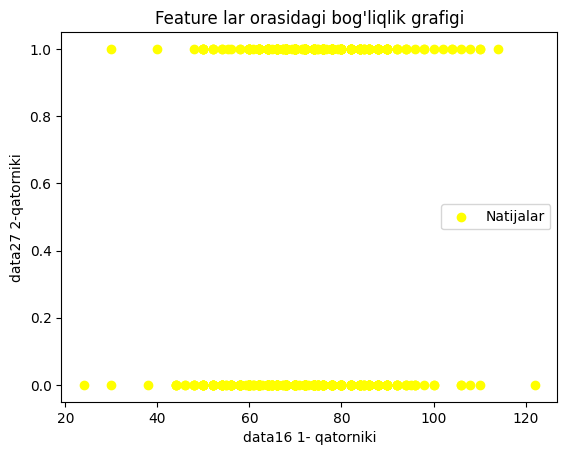

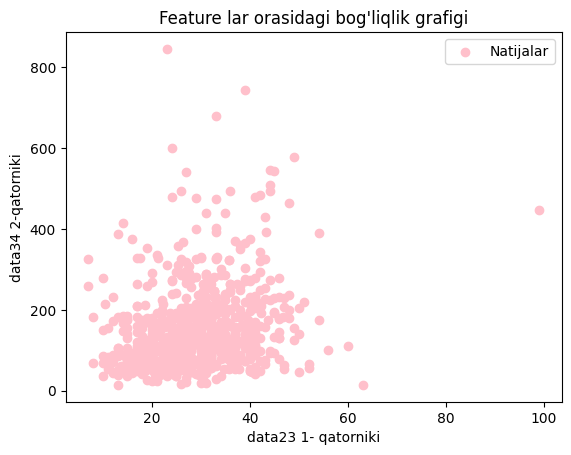

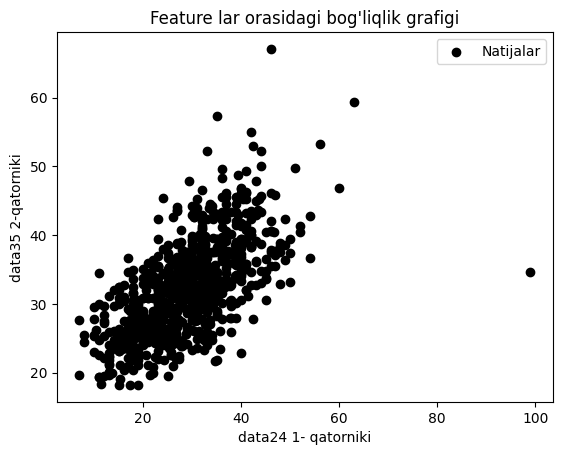

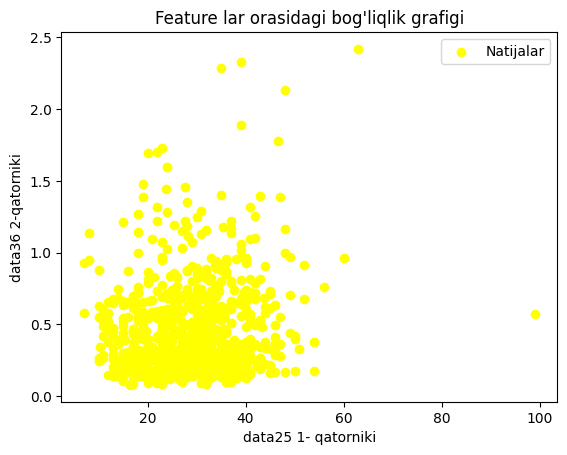

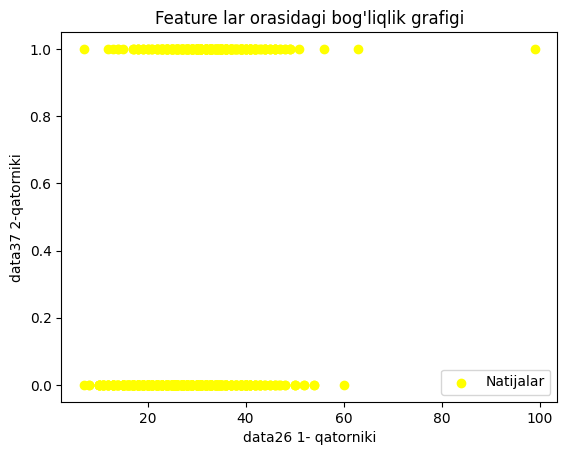

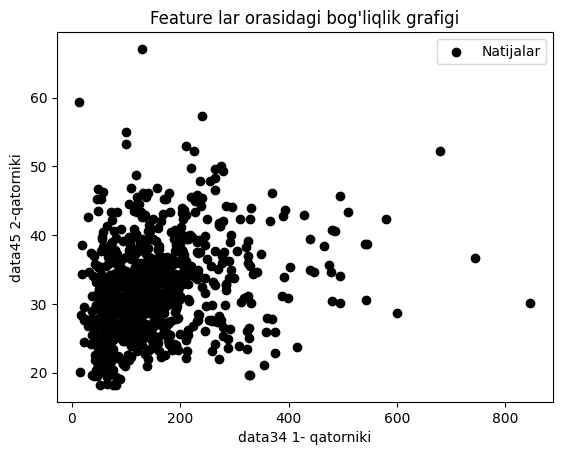

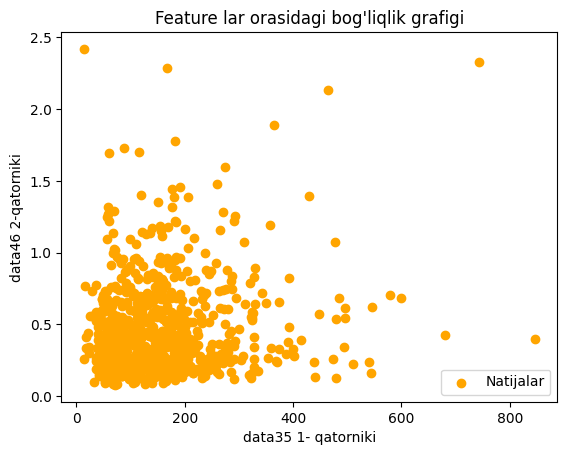

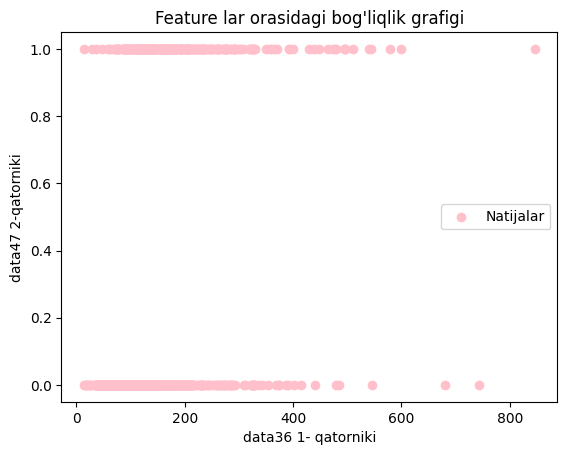

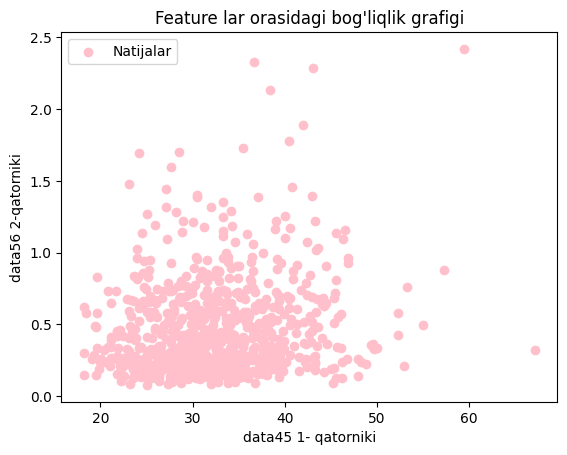

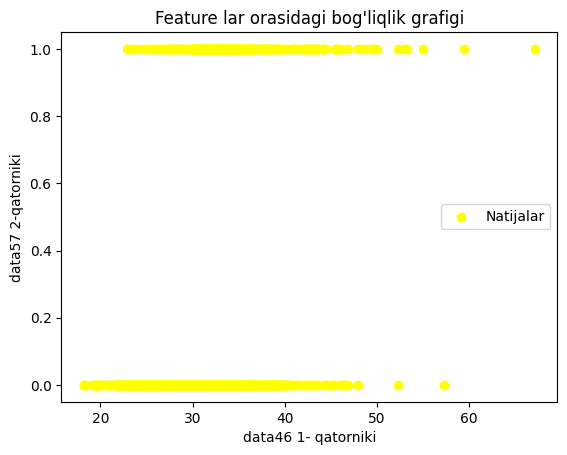

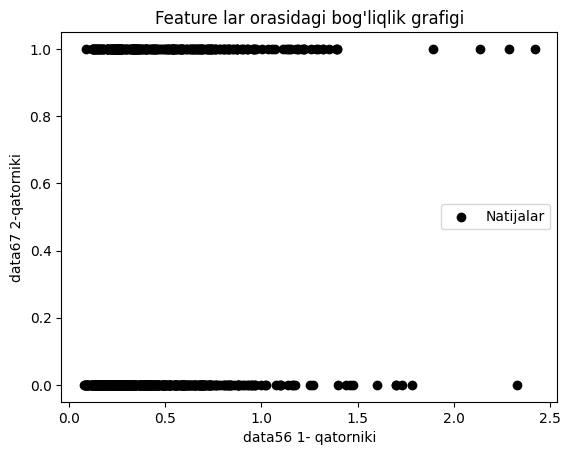

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
data1 =  np.loadtxt('/home/gayratbek/university/leetcode/diabet_new.txt')
data = data1.copy()
k = int(input("K ni kiriting: "))
natija = {}
for i in range(len(data)):
    if 0 in data[i][:-1]: 
        natija[i] = data[i]
# print(natija)
for key, item in natija.items():
    masofalar = {}
    for i in range(len(data)):
        if i  in natija.keys():
            continue
        
        d_kvadratlar = [] 
        for j in range(len(item)):
            if item[j] != 0:
                d_kvadratlar.append((item[j] - data[i][j])**2)
        
        if d_kvadratlar:
            masofalar[i] = float(sum(d_kvadratlar)**0.5)
            
    # print(f"Index {key} uchun masofalar:", masofalar)
    tozalndi = []
    for index, masofa in masofalar.items():
        tozalndi.append([masofa, index])
    tozalndi.sort() 
    
    yaqin_k_ta = tozalndi[:k]
    def imputation():
        for j in range(len(item) - 1):
            if item[j] == 0:
                yangi_qiymatlar = []
                for masofa, index in yaqin_k_ta:
                    yangi_qiymatlar.append(float(data[index][j]))
            
                o_rtacha = sum(yangi_qiymatlar) / len(yangi_qiymatlar)
                data[key][j] = o_rtacha
            
                # print(f"Index {key}, Ustun {j}: 0 o'rniga {o_rtacha:.2f} qo'yildi (K: {yangi_qiymatlar})")
                # print(f"\nToza qator {key} ga eng yaqin {k} ta qo'shni:")
                # for masofa, index in yaqin_k_ta:
                #     print(f"Indeks: {index}, Masofa: {round(masofa, 4)}")
                # print("-" * 35)
    imputation()
# n_data = 0
# def korrelyatsiy():
#     natija = {}
#     for i in range(9):
#         x = data[:, i] 
#         x_mean = np.mean(x)
#         for j in range(i+1, 9):
#             y = data[:, j]
#             y_mean = np.mean(y)
        
#             numerator = np.sum((x - x_mean) * (y - y_mean))
#             denominator = np.sqrt(np.sum((x - x_mean)**2) * np.sum((y - y_mean)**2))
        
#             if denominator != 0:
#                 corr = numerator / denominator
#                 natija[f"{i} va {j}"] = float(corr)
#             else:
#                 natija[f"{i} va {j}"] = 'aniqlab bo`lmadi (variatsiya 0)'
#     # print(natija)
#     # ochirish 8 qator sababbi korrelatsiya 54
#     global n_data
#     n_data = np.delete(data,7,axis=1)
#     print(np.shape(n_data))
# korrelyatsiy()
# n_natija = {}
# for i in range(8):
#     xx = n_data[:,i]
#     x_meann  = np.mean(xx)
#     for j in range(i+1,8):
#          summ = np.sum((xx - x_meann)**2)
#          n_natija[f"{i+1}"] = float(summ / (len(data) -1 ))
# print(n_natija)
# def outliearmi():
#     outliear = {}
#     for i  in range(data.shape[1]):
#         x = data[:,i]
#         q1 = np.percentile(x,25)
#         q3 = np.percentile(x, 75)
#         iqr = q3 - q1
#         bosh_oraliq = x  < q1  - 1.5 * iqr
#         oxirgi_oraliq = x > q3 + 1.5 * iqr
#         outliears = x[bosh_oraliq | oxirgi_oraliq]
#         outliear[f"ustun_{i}"] = outliears
#     print(outliear)
# outliearmi()
# def grafik_korsatadi():
#     for i in range(1,8):
#         x = n_data[:,i] 
#         for j in range(i+1,8):
#             randommi = ['red','yellow','black','orange','green','pink']
#             ran =  random.choice(randommi)
#             plt.scatter(n_data[:,i], n_data[:,j],color=ran , label= 'Natijalar')
#             plt.xlabel(f"data{i-1}{j-1} 1- qatorniki")
#             plt.ylabel(f"data{i}{j} 2-qatorniki")
#             plt.title("Feature lar orasidagi bog'liqlik grafigi")
#             plt.legend()
#             plt.savefig(f'{i}{j} jadvalni Matplotlibdagi grafigi')
#             plt.show()
# grafik_korsatadi()

In [20]:
a = [[1,2],[123,23]]
if 1 in a[0]:
    print(True)
else:
    print(False)


True


In [ ]:

# for key, item in natija.items():
#     masofalar = {}
#     for i in range(len(data)):
#         d_kvadratlar = [] 
#         if i == key:
#             continue
            
#         row_list = data[i].tolist()
#         if 0 in row_list:
#             indexi = row_list.index(0)
#             for j in range(len(item)):
#                 if j != indexi:
#                     d_kvadratlar.append((item[j] - data[i][j])**2)
            
#             if d_kvadratlar:
#                 masofalar[i] = float(sum(d_kvadratlar)**0.5)
#     tozalndi = []
#     for index, masofa in masofalar.items():
#         tozalndi.append([masofa, index])
#     tozalndi.sort() 

#     yaqin_k_ta = tozalndi[:k]
    
#     print(f"\nToza qator {key} ga eng yaqin {k} ta qo'shni:")
#     for masofa, index in yaqin_k_ta:
#         print(f"Indeks: {index}, Masofa: {round(masofa, 4)}")
#     print("-" * 35)
#     def imputation():
#         for masofa, index in yaqin_k_ta:
#             row_list = data[index].tolist()
#             yigindi = 0 
#             count = 0
#             if 0 in row_list:
#                 nol_ustun_indexi = row_list.index(0)
            
#                 yigindi += data[key][nol_ustun_indexi]
#                 count += 1 
            
#                 data[index][nol_ustun_indexi] = yangi_qiymat
            
#                 print(f"Natija: {index}-qatordagi 0 o'rniga {key}-qatordagi {yangi_qiymat} qiymat boldi.")
#     imputation()
#     print("\nTozalangan yangi data to'plami:")
#     print(data)
# data = pd.DataFrame(data)
# data.to_csv("Diabet1_new.csv", index=False)  

    